# Lloyd MinMax Square Latent Storage Visualization

This notebook demonstrates the lloyd_minmax_square algorithm step by step:
1. Load an image from a dataset
2. Encode it through a VAE
3. Visualize the latent channels and the quantization process
4. Show the complete round-trip through serialization/deserialization

In [1]:
# Setup and imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

# Add the project root to path so we can import lsbench
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from lsbench.image.vaes.flux_2_vae import Flux2VAE
from lsbench.image.dataset import ImageDataset
from lsbench.image.latent_storages.lloyd_minmax_square_latent_storage import (
    LloydMinMaxSquareLatentStorage,
)
from lsbench.utils.quantization import (
    to_square_groups,
    quantize_minmax,
    dequantize_minmax,
    from_square_groups,
)
from lsbench.utils.image_tools import torch_to_cv2
from omegaconf import OmegaConf

print("✓ Imports successful")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")

✓ Imports successful
✓ Device: cuda


In [2]:
# Load VAE and dataset
print("Loading Flux 2 VAE...")
vae = Flux2VAE(
    path_to_model=str(project_root / "models" / "FLUX.2-klein-4B" / "vae"),
    device=device,
)
vae.eval()
print(
    f"✓ VAE loaded. Latent channels: {vae.get_latent_channels()}, Spatial compression: {vae.get_spatial_compression()}x"
)

print("\nLoading dataset...")
cfg = OmegaConf.create({"datasets": ["axis-v1_1k"], "width": 1024, "height": 1024})
dataset = ImageDataset(cfg)
print(f"✓ Dataset loaded with {len(dataset)} images")

Loading Flux 2 VAE...
✓ VAE loaded. Latent channels: 3, Spatial compression: 1x

Loading dataset...
✓ Dataset loaded with 1000 images


Loading a sample image...
Image shape: torch.Size([3, 1024, 1024]), dtype: torch.float32, range: [0.000, 0.988]


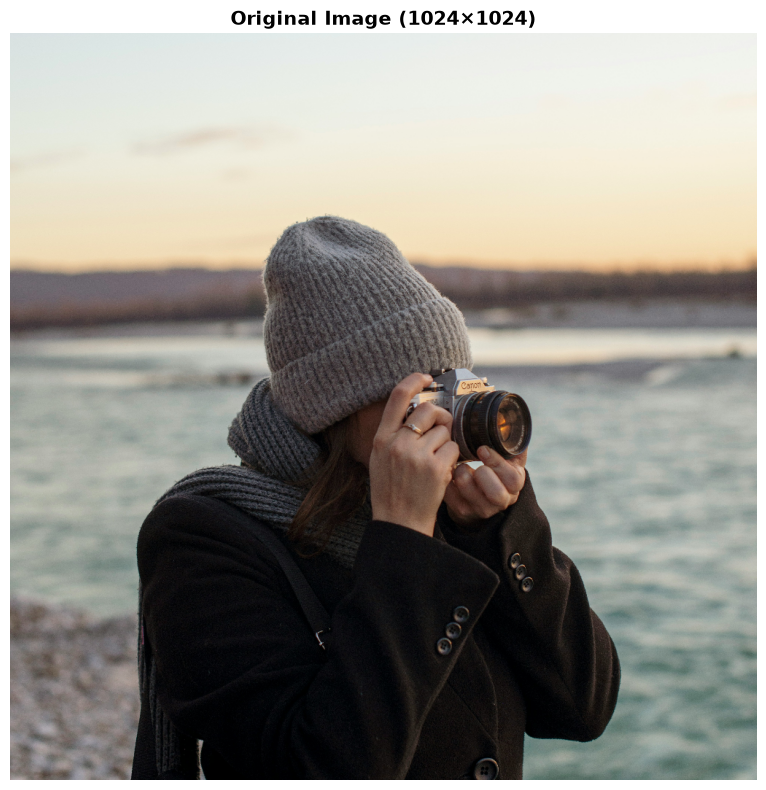

✓ Image displayed


In [23]:
# Load and display an image
print("Loading a sample image...")
image_tensor = dataset[301]  # [3, 1024, 1024] in [0, 1]
print(
    f"Image shape: {image_tensor.shape}, dtype: {image_tensor.dtype}, range: [{image_tensor.min():.3f}, {image_tensor.max():.3f}]"
)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
ax.imshow(image_np)
ax.set_title("Original Image (1024×1024)", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print("✓ Image displayed")

Encoding image through VAE...
Latents shape: torch.Size([32, 128, 128]), dtype: torch.float32, range: [-6.175, 4.857]


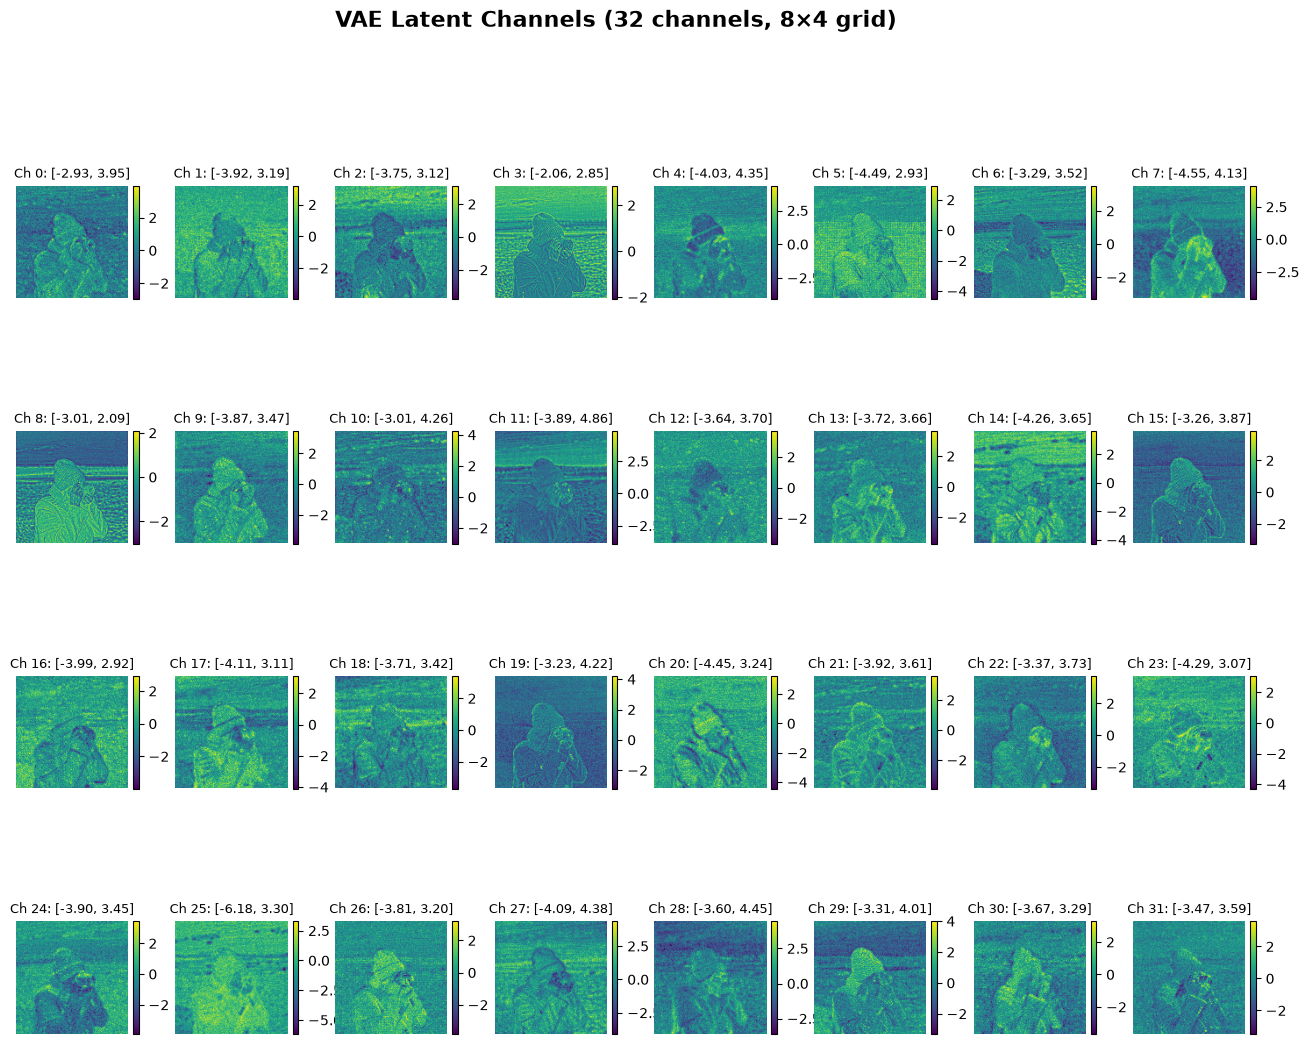

✓ Latents visualized


In [24]:
# Encode image through VAE to get latents
print("Encoding image through VAE...")
with torch.no_grad():
    # Add batch dimension
    image_batch = image_tensor.unsqueeze(0).to(device)
    latents = vae.encode(image_batch)  # [1, C, H, W]

latents = latents.squeeze(0)  # Remove batch dim for visualization
print(
    f"Latents shape: {latents.shape}, dtype: {latents.dtype}, range: [{latents.min():.3f}, {latents.max():.3f}]"
)

# Visualize all 32 channels in an 8x4 grid
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(4, 8, figure=fig, hspace=0.3, wspace=0.3)

for i in range(latents.shape[0]):
    row, col = i // 8, i % 8
    ax = fig.add_subplot(gs[row, col])
    channel_data = latents[i].cpu().numpy()
    im = ax.imshow(channel_data, cmap="viridis")
    ax.set_title(
        f"Ch {i}: [{channel_data.min():.2f}, {channel_data.max():.2f}]", fontsize=9
    )
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "VAE Latent Channels (32 channels, 8×4 grid)",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.show()

print("✓ Latents visualized")

In [ ]:
# Run through Lloyd-MinMax-Square quantization
print("Applying Lloyd-MinMax-Square quantization...")

# Add batch dimension for quantization
latents_batch = latents.unsqueeze(0)

# Parameters
block = 8
bits = 3
range_bits = 6

# Step 1: Group into blocks
groups = to_square_groups(latents_batch, block)  # [B, G, block*block]
print(f"Groups shape: {groups.shape}")

# Step 2: Quantize with Lloyd-Max tables
quant_result = quantize_minmax(
    groups,
    refs=latents_batch.shape[1],  # C channels as reference blocks
    bits=bits,
    range_bits=range_bits,
    lloyd=True,
)

print(f"\nQuantization output:")
for key, val in quant_result.items():
    if isinstance(val, torch.Tensor):
        print(
            f"  {key}: shape={val.shape}, dtype={val.dtype}, size_bytes={val.numel() * val.element_size()}"
        )
    else:
        print(f"  {key}: {val}")

Applying Lloyd-MinMax-Square quantization...
Groups shape: torch.Size([1, 8192, 64])

Quantization output:
  table: shape=torch.Size([1, 8]), dtype=torch.float16, size_bytes=16
  codes: shape=torch.Size([1, 196608]), dtype=torch.uint8, size_bytes=196608
  lo: shape=torch.Size([1, 6144]), dtype=torch.uint8, size_bytes=6144
  hi: shape=torch.Size([1, 6144]), dtype=torch.uint8, size_bytes=6144
  cmin: shape=torch.Size([1, 32]), dtype=torch.float32, size_bytes=128
  cmax: shape=torch.Size([1, 32]), dtype=torch.float32, size_bytes=128


In [26]:
# Unpack and visualize codes
from lsbench.utils.quantization import unpack_bits

print("Unpacking quantization codes...")

# Unpack codes
b, n_groups, group_size = groups.shape
codes = unpack_bits(quant_result["codes"], n_groups * group_size, bits).reshape(
    b, n_groups, group_size
)
codes_squeezed = codes.squeeze(0)
print(f"Codes shape: {codes.shape}, values range: [{codes.min()}, {codes.max()}]")

# Unpack lo, hi
lo = (
    unpack_bits(quant_result["lo"], n_groups, range_bits)
    .reshape(b, n_groups)
    .squeeze(0)
)
hi = (
    unpack_bits(quant_result["hi"], n_groups, range_bits)
    .reshape(b, n_groups)
    .squeeze(0)
)
print(f"Lo shape: {lo.shape}, range: [{lo.min()}, {lo.max()}]")
print(f"Hi shape: {hi.shape}, range: [{hi.min()}, {hi.max()}]")

# cmin, cmax are already float tensors
cmin = quant_result["cmin"].squeeze(0)  # [C]
cmax = quant_result["cmax"].squeeze(0)  # [C]
print(f"Cmin shape: {cmin.shape}, range: [{cmin.min():.3f}, {cmin.max():.3f}]")
print(f"Cmax shape: {cmax.shape}, range: [{cmax.min():.3f}, {cmax.max():.3f}]")

# Lloyd tables
if "table" in quant_result:
    tables = quant_result["table"].squeeze(0)  # [C, 2^bits]
    print(f"Lloyd tables shape: {tables.shape}, dtype: {tables.dtype}")
    print(f"Table value ranges:")
    for i, table in enumerate(tables):
        print(f"  Ch {i}: [{table.min():.4f}, {table.max():.4f}]")

Unpacking quantization codes...
Codes shape: torch.Size([1, 8192, 64]), values range: [0, 7]
Lo shape: torch.Size([8192]), range: [0, 40]
Hi shape: torch.Size([8192]), range: [24, 63]
Cmin shape: torch.Size([32]), range: [-6.175, -2.060]
Cmax shape: torch.Size([32]), range: [2.093, 4.857]
Lloyd tables shape: torch.Size([8]), dtype: torch.float16
Table value ranges:
  Ch 0: [0.0710, 0.0710]
  Ch 1: [0.2207, 0.2207]
  Ch 2: [0.3398, 0.3398]
  Ch 3: [0.4478, 0.4478]
  Ch 4: [0.5527, 0.5527]
  Ch 5: [0.6597, 0.6597]
  Ch 6: [0.7773, 0.7773]
  Ch 7: [0.9272, 0.9272]


Latent spatial: 128×128, blocks: 16×16, channels: 32
Codes spatial shape: torch.Size([32, 128, 128])


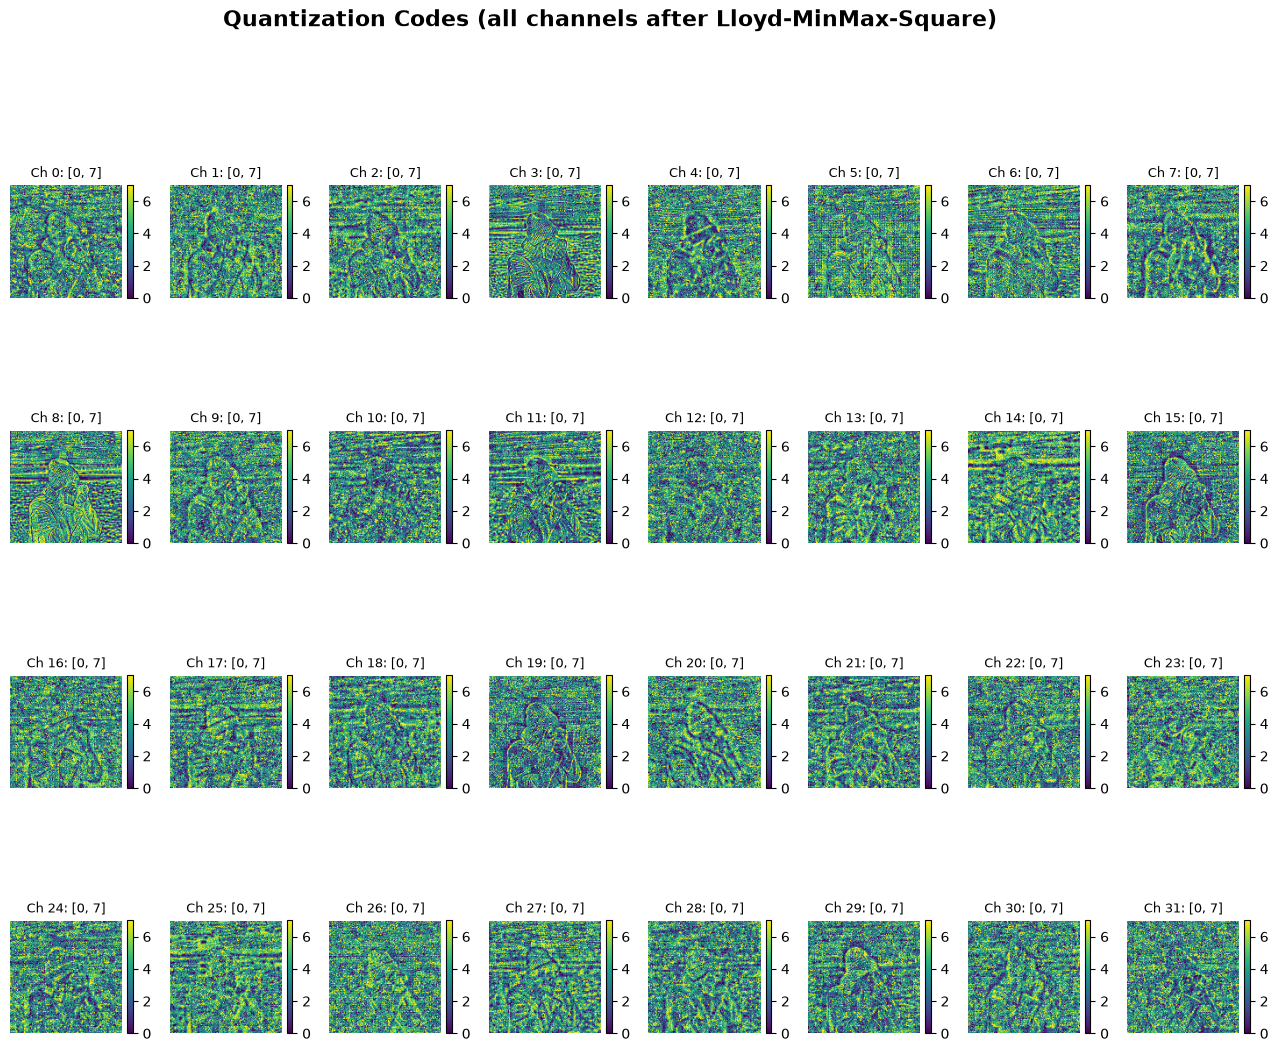

✓ Codes visualization complete


In [27]:
# Visualize codes for all 32 channels in 4x8 grid (like latent channels above)
# Reshape codes back to full spatial dimensions for each channel
# codes_squeezed shape: [C*hb*wb, block*block]

import math

# Compute spatial dimensions
C = latents_batch.shape[1]  # 32 channels
H, W = latents_batch.shape[2], latents_batch.shape[3]  # 128, 128
hb = math.ceil(H / block)  # blocks in height
wb = math.ceil(W / block)  # blocks in width

print(f"Latent spatial: {H}×{W}, blocks: {hb}×{wb}, channels: {C}")

# Reshape codes to [C, hb, wb, block, block]
codes_reshaped = codes_squeezed.reshape(C, hb, wb, block, block)

# Permute to [C, hb, block, wb, block] then reshape to [C, H, W]
# This reconstructs the spatial layout of codes per channel
codes_spatial = codes_reshaped.permute(0, 1, 3, 2, 4).reshape(C, hb * block, wb * block)

# Crop to original spatial dimensions
codes_spatial = codes_spatial[:, :H, :W]

print(f"Codes spatial shape: {codes_spatial.shape}")

# Display all 32 channels in 8x4 grid
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(4, 8, figure=fig, hspace=0.3, wspace=0.3)

for i in range(C):
    row, col = i // 8, i % 8
    ax = fig.add_subplot(gs[row, col])
    codes_ch = codes_spatial[i].cpu().numpy()
    im = ax.imshow(codes_ch, cmap="viridis", vmin=0, vmax=2**bits - 1)
    ax.set_title(f"Ch {i}: [{codes_ch.min():.0f}, {codes_ch.max():.0f}]", fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "Quantization Codes (all channels after Lloyd-MinMax-Square)",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.show()

print("✓ Codes visualization complete")

Lloyd-Max table shape: torch.Size([8]), dtype: torch.float16
Table value range: [0.0710, 0.9272]


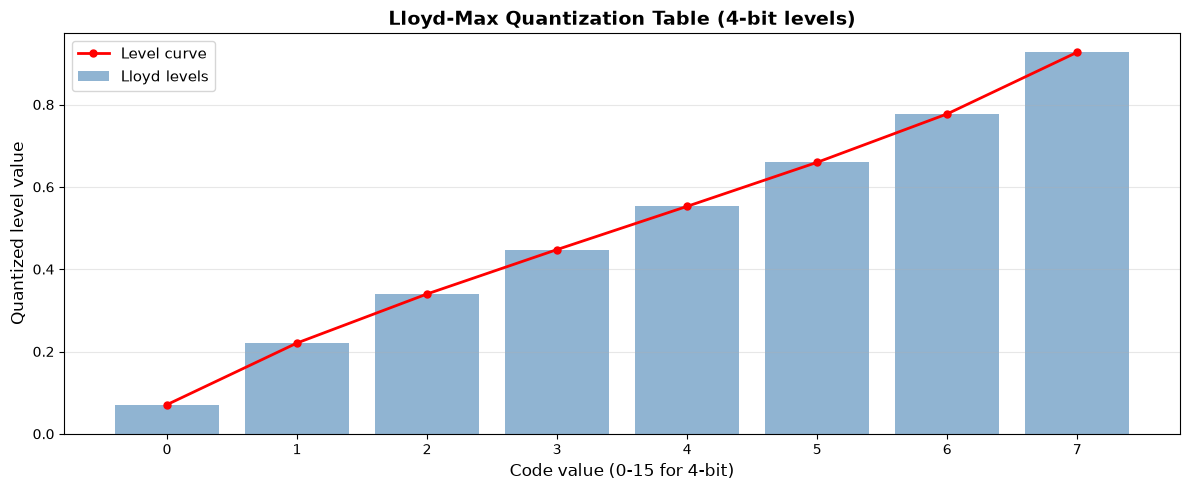

✓ Lloyd table visualized


In [28]:
# Visualize Lloyd-Max table (distribution)
if "table" in quant_result:
    # In Lloyd mode, there's one table per sample (not per channel)
    table = quant_result["table"].squeeze(0)  # Remove batch dimension -> [2^bits]

    print(f"Lloyd-Max table shape: {table.shape}, dtype: {table.dtype}")
    print(f"Table value range: [{table.min():.4f}, {table.max():.4f}]")

    fig, ax = plt.subplots(figsize=(12, 5))
    table_np = table.cpu().numpy()

    # Plot the table as both bar chart and line
    ax.bar(
        range(len(table_np)),
        table_np,
        alpha=0.6,
        color="steelblue",
        label="Lloyd levels",
        width=0.8,
    )
    ax.plot(table_np, "r.-", linewidth=2, markersize=10, label="Level curve")

    ax.set_title(
        "Lloyd-Max Quantization Table (4-bit levels)", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Code value (0-15 for 4-bit)", fontsize=12)
    ax.set_ylabel("Quantized level value", fontsize=12)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    print("✓ Lloyd table visualized")
else:
    print("No Lloyd tables in result (not using Lloyd mode)")

In [29]:
# Complete round-trip: serialize, deserialize, decode
print("Running complete round-trip...\n")

# Initialize storage
storage = LloydMinMaxSquareLatentStorage(bits=bits, block=block, range_bits=range_bits)
print(f"Storage: {storage.get_storage_name()}")

# Serialize
print("\n1. Serializing latents...")
serialized_bytes = storage.serialize(latents_batch)
print(f"   Original latents size: {latents_batch.numel() * 4} bytes (float32)")
print(f"   Serialized size: {len(serialized_bytes)} bytes")
compression_ratio = (latents_batch.numel() * 4) / len(serialized_bytes)
print(f"   Compression ratio: {compression_ratio:.2f}x")

# Deserialize
print("\n2. Deserializing...")
latents_reconstructed = storage.deserialize(serialized_bytes, device=device)
print(f"   Reconstructed latents shape: {latents_reconstructed.shape}")
print(
    f"   Reconstructed latents range: [{latents_reconstructed.min():.3f}, {latents_reconstructed.max():.3f}]"
)

# Compare quantization error
quant_error = (latents_batch - latents_reconstructed).abs()
print(f"\n3. Quantization error statistics:")
print(f"   Max absolute error: {quant_error.max():.6f}")
print(f"   Mean absolute error: {quant_error.mean():.6f}")
print(f"   Std dev: {quant_error.std():.6f}")
mse = (quant_error**2).mean()
print(f"   MSE: {mse:.6f}")
psnr = 20 * np.log10(1.0 / np.sqrt(mse.cpu().numpy() + 1e-10))
print(f"   PSNR: {psnr:.2f} dB")

print("\n✓ Serialization/deserialization complete")

Running complete round-trip...

Storage: lloyd_minmax_square_c3_b8_r6

1. Serializing latents...
   Original latents size: 2097152 bytes (float32)
   Serialized size: 209648 bytes
   Compression ratio: 10.00x

2. Deserializing...
   Reconstructed latents shape: torch.Size([1, 32, 128, 128])
   Reconstructed latents range: [-5.694, 4.362]

3. Quantization error statistics:
   Max absolute error: 0.521553
   Mean absolute error: 0.099284
   Std dev: 0.066521
   MSE: 0.014282
   PSNR: 18.45 dB

✓ Serialization/deserialization complete


Decoding reconstructed latents...
Reconstructed image shape: torch.Size([3, 1024, 1024]), range: [0.000, 0.975]


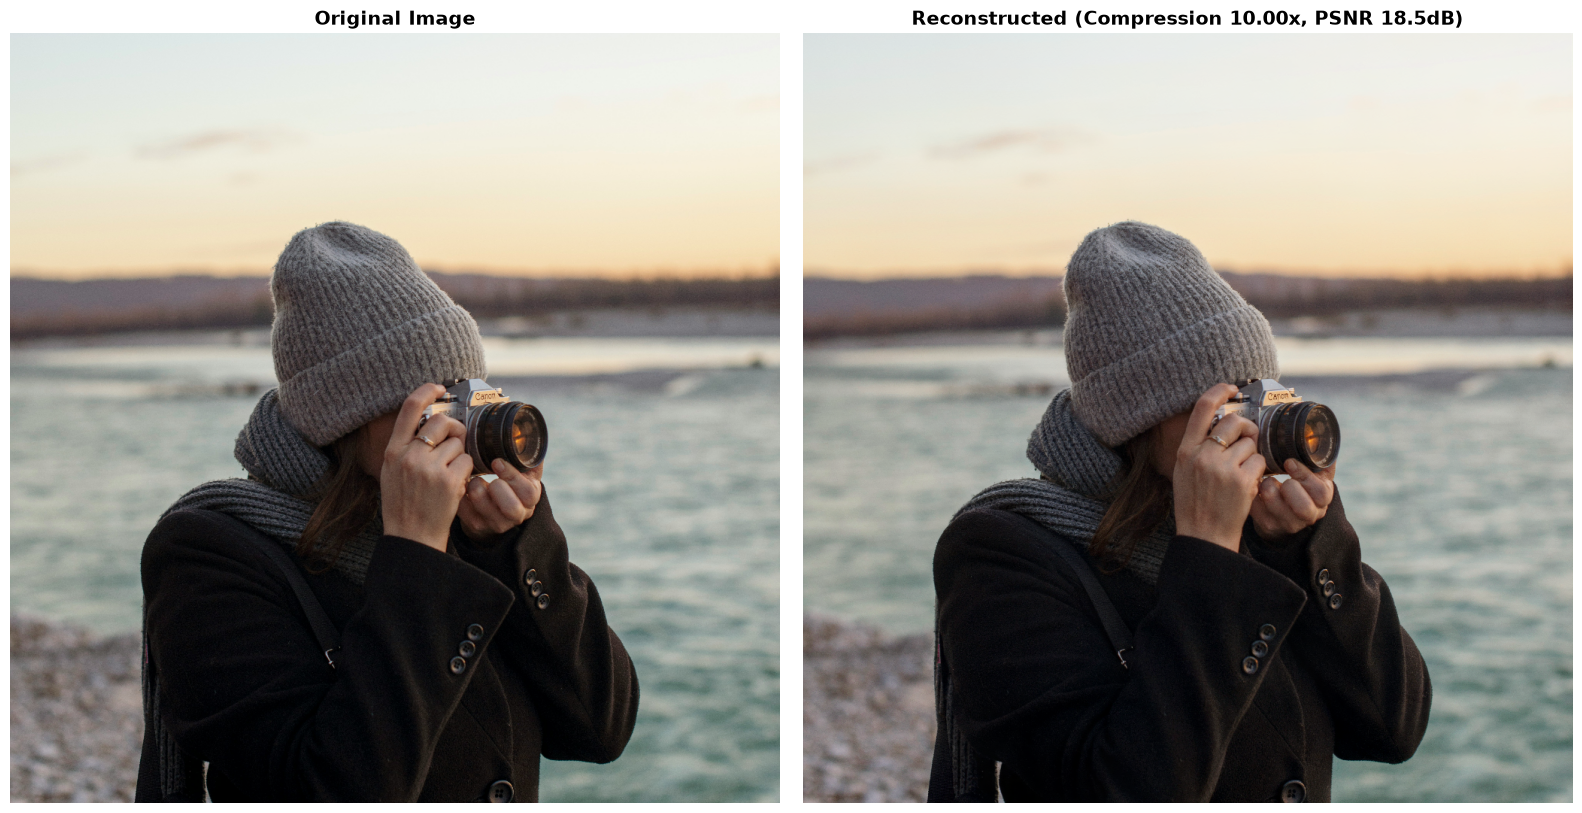

✓ Reconstruction visualization complete


In [30]:
# Decode reconstructed latents
print("Decoding reconstructed latents...")
with torch.no_grad():
    reconstructed_image = vae.decode(latents_reconstructed)

reconstructed_image = reconstructed_image.squeeze(0).clamp(0, 1)
print(
    f"Reconstructed image shape: {reconstructed_image.shape}, range: [{reconstructed_image.min():.3f}, {reconstructed_image.max():.3f}]"
)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

original_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
reconstructed_np = reconstructed_image.cpu().numpy().transpose(1, 2, 0)

axes[0].imshow(original_np)
axes[0].set_title("Original Image", fontsize=14, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(reconstructed_np)
axes[1].set_title(
    f"Reconstructed (Compression {compression_ratio:.2f}x, PSNR {psnr:.1f}dB)",
    fontsize=14,
    fontweight="bold",
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("✓ Reconstruction visualization complete")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.3803828].


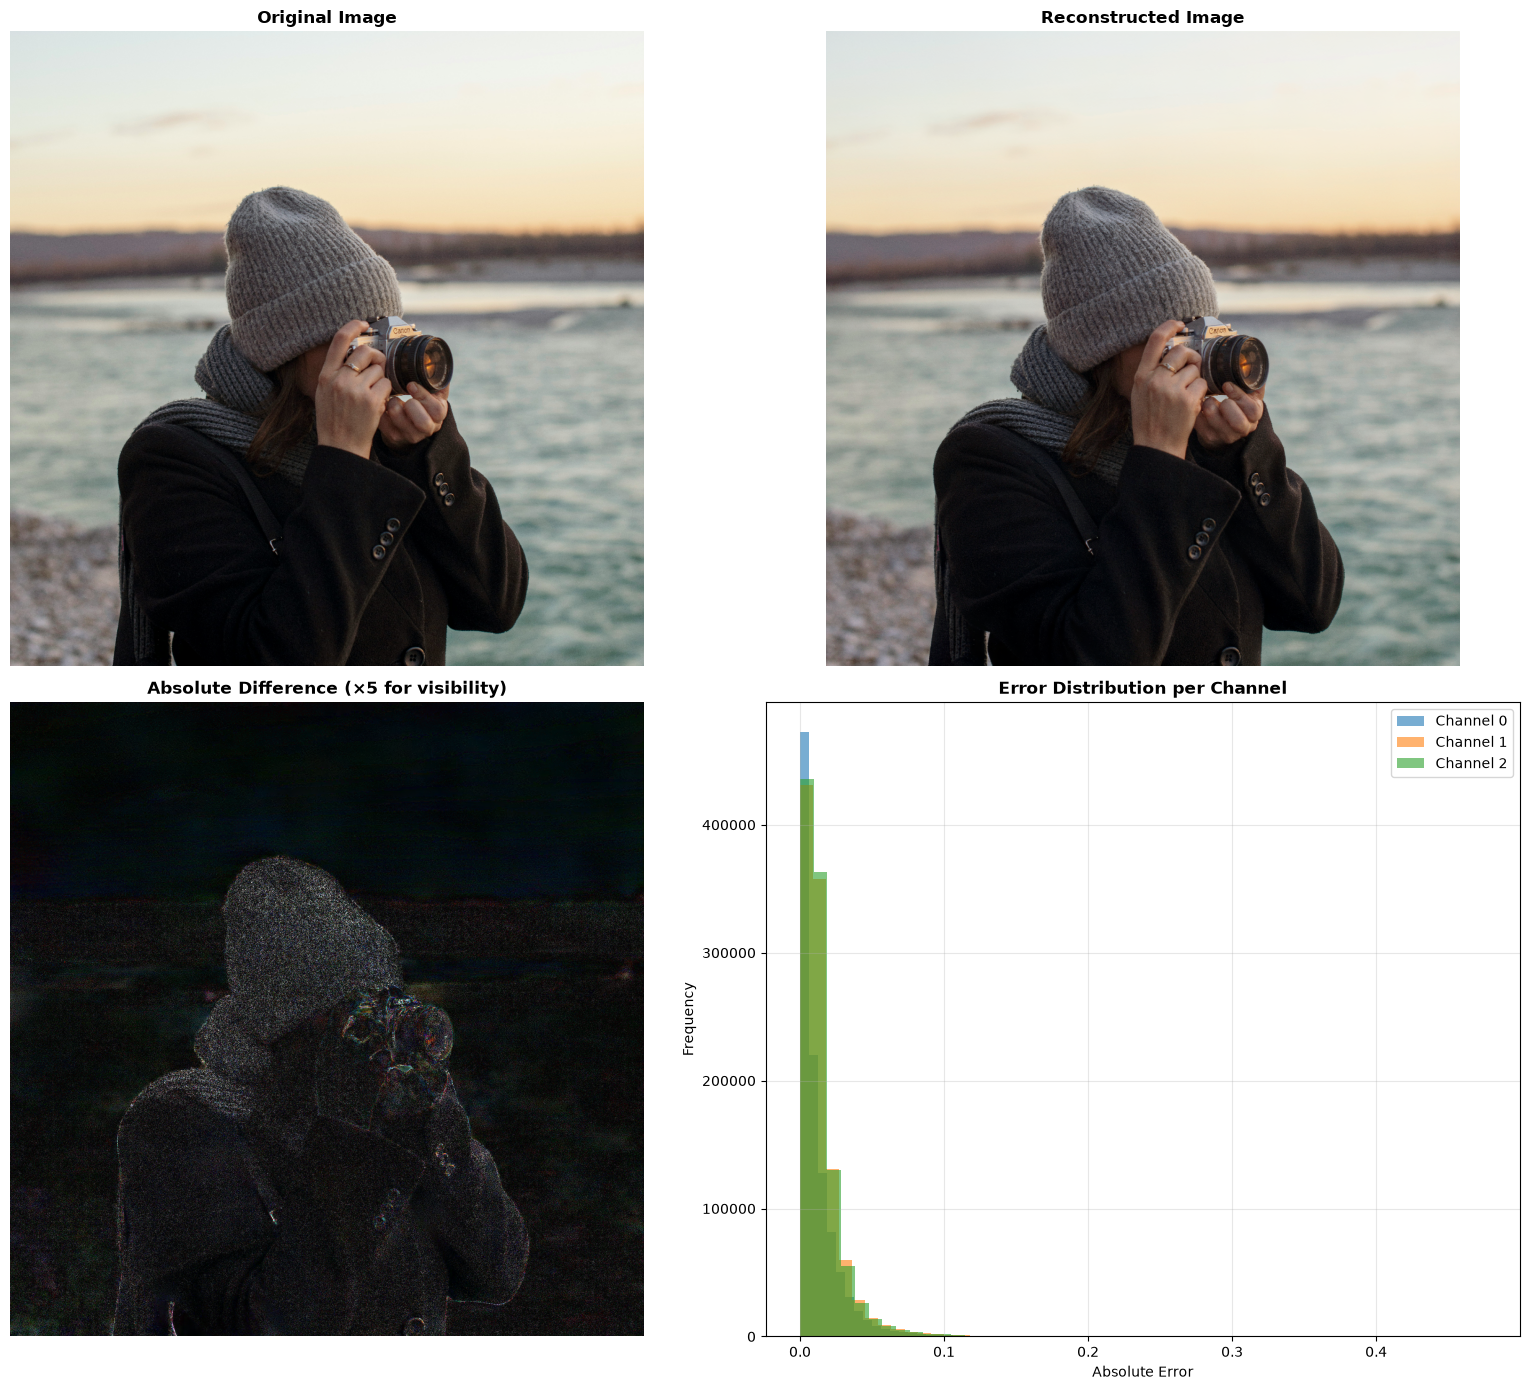

✓ Analysis complete


In [31]:
# Show difference map
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

original_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
reconstructed_np = reconstructed_image.cpu().numpy().transpose(1, 2, 0)
diff = np.abs(original_np - reconstructed_np)

# Original
axes[0, 0].imshow(original_np)
axes[0, 0].set_title("Original Image", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

# Reconstructed
axes[0, 1].imshow(reconstructed_np)
axes[0, 1].set_title("Reconstructed Image", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

# Difference (scaled for visibility)
axes[1, 0].imshow(diff * 5, cmap="hot")  # Scale up for visibility
axes[1, 0].set_title(
    "Absolute Difference (×5 for visibility)", fontsize=12, fontweight="bold"
)
axes[1, 0].axis("off")

# Error histogram per channel
for ch in range(3):
    ch_error = diff[:, :, ch]
    axes[1, 1].hist(ch_error.flatten(), bins=50, alpha=0.6, label=f"Channel {ch}")
axes[1, 1].set_title("Error Distribution per Channel", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Absolute Error")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Analysis complete")